In [9]:
# Import packages
from pathlib import Path
import numpy as np
from numpy.random import MT19937
from numpy.random import RandomState, SeedSequence
import pandas as pd
import random
from pdb import set_trace

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

### Testing sets performance and subsequent analyses with model trained with ranked protein abundance profiles labeled with **modified** marker protein localizations

In [10]:
# Check to see if the GPU is available and store it as a variable so tensors can be moved to it
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)
print('Is cuda available?:', torch.cuda.is_available())
print('cuda version:', torch.version.cuda)
dev = "cuda:0"

Using device: cuda
Is cuda available?: True
cuda version: 11.7


In [33]:
# Create run name
Run_Name = 'Prot' # change run_name before running

# Paths
label_path = '/home/ec2-user/Jul2025/labels/' # label folder with all the labels
dataset_folder_path = '/home/ec2-user/Jul2025/processed_datasets_unfiltered/' # dataset folder with all the processed proteome and mRNA data
model_folder_path = '/home/ec2-user/Jul2025/saved_models/' # model folder with all the models
enrichr_path = '/home/ec2-user/Jul2025/Fig5_Enrichr_Ranked_Prot_Modified_Marker_Localization/'

# Define the Model
Model = 'PixelPreserve'
pth_path = 'saved_models/Protein_NN_ranked_modified1_model.pth'

# Dataset
Set = 'Protein' 

# Image size
Canvas_Size = 18

# Seed number
Seed = 43

# Batch size
Batch_size = 64

In [12]:
def set_seed(seed):
    random.seed(seed) # set random seed for python
    np.random.seed(seed) # set random seed for numpy
    torch.manual_seed(seed) # set random seed for CPU
    rs = RandomState(MT19937(SeedSequence(seed))) # seed for numpy
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed) # set random seed for all GPUs
    torch.backends.cudnn.deterministic = True # set to True to get reproducible results
    torch.backends.cudnn.benchmark = False # set to False to get reproducible results

In [13]:
def gen_horizontal_coords(n, num_points):
    """
    Generate coordinates for a horizontal pattern starting from the top-left corner.

    Parameters:
    n (int): Size of the canvas (n x n).
    num_points (int): Number of points to generate in the horizontal pattern.

    Returns:
    list: List of (x, y) coordinates in horizontal order.
    """
    coords = [(x, y) for x in range(n) for y in range(n)]
    return coords[:num_points]

def create_rgb_tensors(set, interleaved_array):
    """
    Create RGB tensors from abundance data using the specified pattern.
    
    Parameters:
    set (str): Dataset used for plotting ('Protein', 'mRNA', 'Protein + mRNA').
    df1 (pd.DataFrame): DataFrame containing normalized abundance data.
    df2 (pd.DataFrame): DataFrame containing normalized abundance data.
    
    Returns:
    torch.Tensor: RGB tensor.
    """

    interleaved_array = interleaved_array.flatten()
    num_pixels = len(interleaved_array)
    
    # Generate coordinates based on the pattern, spiral or horizontal arrangment
    coords = gen_horizontal_coords(Canvas_Size, num_pixels)

    # Create RGB tensor
    rgb_tensor = np.zeros((Canvas_Size, Canvas_Size, 3), dtype=np.float32)
    for i, (x, y) in enumerate(coords):
        if i < len(interleaved_array):
            value = interleaved_array[i]
            # Assign colors based on the value, if abundance > 1, set it to red, if abundance < 0, set it to blue.
            #if value > 1:
            #    rgb_tensor[x, y] = [255, 0, 0]  # Red for value > 1
            #elif value < 0:
            #    rgb_tensor[x, y] = [0, 0, 255]  # Blue for value < 0
            #else:
            rgb_tensor[x, y] = [255 * value, 0, 255 * (1 - value)]

    return torch.from_numpy(rgb_tensor.transpose(2, 0, 1))  # Convert to CHW format for PyTorch

In [14]:
class MyDataset(Dataset):
    def __init__(self, set, data1, data2, indices, labels, transform=None):

        assert data1.loc[indices,:].shape[0] == data2.loc[indices,:].shape[0] == len(labels), \
            "Protein, mRNA, and labels must have the same number of samples (rows)"

        self.set = set
        self.data1 = data1.loc[indices,:]
        self.data2 = data2.loc[indices,:]
        self.indices = indices
        self.labels = labels
        self.transform = transform

    def __getitem__(self, idx):
        data1 = self.data1.iloc[idx].values
        data2 = self.data2.iloc[idx].values

        if self.transform:  
            data1, data2 = self.transform(data1, data2)

        abundance_sum = data1 + data2
        sorted_idx = abundance_sum.argsort()

        # Interleave
        interleaved_data = np.empty((len(data1) + len(data2)), dtype=np.float32)
        interleaved_data[0::2] = data1[sorted_idx]
        interleaved_data[1::2] = data2[sorted_idx]

        # Create RGB tensor
        sample = create_rgb_tensors(self.set, interleaved_data)
        label = torch.tensor(self.labels[idx], dtype=torch.long)
        index = self.indices[idx]

        return sample, label, index

    def __len__(self):
        return len(self.labels)

    def get_labels(self):
        return self.labels

In [15]:
# Open the labels data
LFP = 'markers_modified_1.txt'
LD = pd.read_csv(filepath_or_buffer=label_path+LFP,sep='\t')

# Data set wrangling
LD.index = LD.loc[:,'Protein']
LD = LD.loc[:,LD.columns!='Protein']

In [16]:
# Labels
localization_labels = LD.loc[:, 'Localization'].values
unique_labels = set(localization_labels)  # Get unique labels
label_to_int = {
    'Cytosol': 0,
    'Mitochondria': 1,
    'Nucleus': 2,
    'Secretory': 3
}
int_to_label = {v: k for k, v in label_to_int.items()}
int_to_label

{0: 'Cytosol', 1: 'Mitochondria', 2: 'Nucleus', 3: 'Secretory'}

In [17]:
class PixelPreservingNet(nn.Module):
    def __init__(self, in_channels=3):
        super(PixelPreservingNet, self).__init__()
        
        # Convolutional layers
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=16, kernel_size=3, padding=1), 
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout(0.3)  
        )  # Shape remains same after padding

        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)  # Shape is reduced by half

        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(0.3)  
        )  # Shape remains same after padding

        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(0.3)  
        )  # Shape remains same after padding

        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Dropout(0.3)  
        )  # Shape remains same after padding

        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Dropout(0.3)  
        )

        # Fully connected layers
        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)  # Global Average Pooling layer
        self.fc1 = nn.Sequential(
            nn.Linear(256, 512), #256->512
            nn.ReLU(),
            nn.Dropout(0.4)
        )
        self.fc2 = nn.Sequential(
            nn.Linear(512, 256), #512->256
            nn.ReLU(),
            nn.Dropout(0.4)
        )

        # Output layer
        self.output = nn.Linear(256, 4) #256->4
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.pool(x)
        x = self.conv2(x)
        x = self.pool(x)
        x = self.conv3(x)
        x = self.pool(x)
        x = self.conv4(x)
        x = self.pool(x)
        x = self.conv5(x)
        
        # Global Average Pooling
        x = self.global_avg_pool(x)
        x = torch.flatten(x, 1)
        
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.output(x)
        return x

model = PixelPreservingNet(in_channels=3).to(device)

In [18]:
# Function to calculate the precision and recall
def calculate_metrics(dataloader, model):
    y_pred = []
    y_true = []
    all_indices = []
    all_predicted_labels = []
    all_true_labels = []

    model.eval()
    with torch.no_grad():
        # iterate over validation data
        for X, y, idx in dataloader:
            X = X.to(torch.float32)
            X = X.to(device)
            output = model(X)  # Feed Network

            output = (torch.max(torch.exp(output), 1)[1]).data.cpu().numpy()
            labels = y.cpu().numpy()

            y_pred.extend(output)  # Save Prediction
            y_true.extend(labels)  # Save Truth
            all_indices.extend(idx)
            all_predicted_labels.extend(output)
            all_true_labels.extend(labels)

    # Calculate confusion matrix
    cf_matrix = confusion_matrix(y_true, y_pred)

    # Calculate precision and recall for each class
    precision = precision_score(y_true, y_pred, average=None, zero_division=0)
    recall = recall_score(y_true, y_pred, average=None, zero_division=0)
    macro_f1 = f1_score(y_true, y_pred, average='macro')

    # Return all indices, their predictions, and true labels
    return cf_matrix, precision, recall, macro_f1, all_indices, all_predicted_labels, all_true_labels

In [19]:
# make a function that visualize 5 confusion matrices from 5 data loaders, and stack them into one figure, 3 by 2
def plot_confusion_matrices(cf_matrices, labels, title):
    fig, axes = plt.subplots(2, 3, figsize=(10, 6))
    axes = axes.flatten()
    
    for i, cf_matrix in enumerate(cf_matrices):
        sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
                    xticklabels=labels, yticklabels=labels, ax=axes[i])
        #axes[i].set_xlabel('Predicted')
        #axes[i].set_ylabel('True')
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45)
        axes[i].set_title(title[i])
    
    # remove the last empty subplot
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    # set an overall x and y label for the entire figure
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])  # Adjust layout to make space for the title
    fig.subplots_adjust(hspace=0.4, wspace=0.4)
    fig.text(0.5, 0, 'Predicted', ha='center', fontdict={'size': 16})
    fig.text(0, 0.5, 'True', va='center', rotation='vertical', fontdict={'size': 16})

    #fig.xlabel('Predicted')
    #fig.ylabel('True')
    plt.tight_layout()
    plt.show()

In [20]:
# Load the model
last_model = PixelPreservingNet(in_channels=3)
last_model.load_state_dict(torch.load(pth_path))
last_model.to(device)

PixelPreservingNet(
  (conv1): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (pool): AvgPool2d(kernel_size=2, stride=2, padding=0)
  (conv2): Sequential(
    (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (conv3): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
  )
  (conv4): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True

In [21]:
# Read in the synthetic data
# Mertins 
#   proteome
M_PD_synthetic = pd.read_csv(Path(dataset_folder_path+'breast_tumor_PD_processed_unfiltered.csv'))
M_PD_synthetic.index = M_PD_synthetic.loc[:,'Unnamed: 0']
M_PD_synthetic = M_PD_synthetic.loc[:, M_PD_synthetic.columns!='Unnamed: 0']

#   transcriptome
M_MD_synthetic = pd.read_csv(Path(dataset_folder_path+'breast_tumor_MD_processed_unfiltered.csv'))
M_MD_synthetic.index = M_MD_synthetic.loc[:,'Unnamed: 0']
M_MD_synthetic = M_MD_synthetic.loc[:, M_MD_synthetic.columns!='Unnamed: 0']

# LCSCC tumor
#   proteome
lung_tumor_PD_synthetic = pd.read_csv(Path(dataset_folder_path+'lung_tumor_PD_processed_unfiltered.csv'))
lung_tumor_PD_synthetic.index = lung_tumor_PD_synthetic.loc[:,'Unnamed: 0']
lung_tumor_PD_synthetic = lung_tumor_PD_synthetic.loc[:, lung_tumor_PD_synthetic.columns!='Unnamed: 0']

#   transcriptome
lung_tumor_MD_synthetic = pd.read_csv(Path(dataset_folder_path+'lung_tumor_MD_processed_unfiltered.csv'))
lung_tumor_MD_synthetic.index = lung_tumor_MD_synthetic.loc[:,'Unnamed: 0']
lung_tumor_MD_synthetic = lung_tumor_MD_synthetic.loc[:, lung_tumor_MD_synthetic.columns!='Unnamed: 0']

# LCSCC NAT
#   proteome
lung_nat_PD_synthetic = pd.read_csv(Path(dataset_folder_path+'lung_nat_PD_processed_unfiltered.csv'))
lung_nat_PD_synthetic.index = lung_nat_PD_synthetic.loc[:,'Unnamed: 0']
lung_nat_PD_synthetic = lung_nat_PD_synthetic.loc[:, lung_nat_PD_synthetic.columns!='Unnamed: 0']

#   transcriptome
lung_nat_MD_synthetic = pd.read_csv(Path(dataset_folder_path+'lung_nat_MD_processed_unfiltered.csv'))
lung_nat_MD_synthetic.index = lung_nat_MD_synthetic.loc[:,'Unnamed: 0']
lung_nat_MD_synthetic = lung_nat_MD_synthetic.loc[:, lung_nat_MD_synthetic.columns!='Unnamed: 0']

# Brain glioma
#   proteome
glioma_PD_synthetic = pd.read_csv(Path(dataset_folder_path+'brain_tumor_PD_processed_unfiltered.csv'))
glioma_PD_synthetic.index = glioma_PD_synthetic.loc[:,'gene_name']
glioma_PD_synthetic = glioma_PD_synthetic.loc[:, glioma_PD_synthetic.columns!='gene_name']

#   transcriptome
glioma_MD_synthetic = pd.read_csv(Path(dataset_folder_path+'brain_tumor_MD_processed_unfiltered.csv'))
glioma_MD_synthetic.index = glioma_MD_synthetic.loc[:,'gene_name']
glioma_MD_synthetic = glioma_MD_synthetic.loc[:, glioma_MD_synthetic.columns!='gene_name']

In [22]:
M_common_indices = list(set(M_PD_synthetic.index).intersection(set(M_MD_synthetic.index).intersection(set(LD.index))))
M_LD = LD.loc[LD.index.isin(M_common_indices)]
M_PD_synthetic = M_PD_synthetic.loc[M_PD_synthetic.index.isin(M_common_indices)]
M_MD_synthetic = M_MD_synthetic.loc[M_MD_synthetic.index.isin(M_common_indices)]

lung_tumor_common_indices = list(set(lung_tumor_PD_synthetic.index).intersection(set(lung_tumor_MD_synthetic.index).intersection(set(LD.index))))
lung_tumor_LD = LD.loc[LD.index.isin(lung_tumor_common_indices)]
lung_tumor_PD_synthetic = lung_tumor_PD_synthetic.loc[lung_tumor_PD_synthetic.index.isin(lung_tumor_common_indices)]
lung_tumor_MD_synthetic = lung_tumor_MD_synthetic.loc[lung_tumor_MD_synthetic.index.isin(lung_tumor_common_indices)]

lung_nat_common_indices = list(set(lung_nat_PD_synthetic.index).intersection(set(lung_nat_MD_synthetic.index).intersection(set(LD.index))))
lung_nat_LD = LD.loc[LD.index.isin(lung_nat_common_indices)]
lung_nat_PD_synthetic = lung_nat_PD_synthetic.loc[lung_nat_PD_synthetic.index.isin(lung_nat_common_indices)]
lung_nat_MD_synthetic = lung_nat_MD_synthetic.loc[lung_nat_MD_synthetic.index.isin(lung_nat_common_indices)]

glioma_common_indices = list(set(glioma_PD_synthetic.index).intersection(set(glioma_MD_synthetic.index).intersection(set(LD.index))))
glioma_LD = LD.loc[LD.index.isin(glioma_common_indices)]
glioma_PD_synthetic = glioma_PD_synthetic.loc[glioma_PD_synthetic.index.isin(glioma_common_indices)]
glioma_MD_synthetic = glioma_MD_synthetic.loc[glioma_MD_synthetic.index.isin(glioma_common_indices)]

In [23]:
# Convert string labels to integers
M_test_labels = [label_to_int[label] for label in M_LD['Localization'].values]
lung_tumor_test_labels = [label_to_int[label] for label in lung_tumor_LD['Localization'].values]
lung_nat_test_labels = [label_to_int[label] for label in lung_nat_LD['Localization'].values]
glioma_test_labels = [label_to_int[label] for label in glioma_LD['Localization'].values]

# Create the test datasets
if Set == 'Protein':
    M_test_dataset = MyDataset(Set, M_PD_synthetic, M_PD_synthetic, M_PD_synthetic.index, M_test_labels)
    lung_tumor_test_dataset = MyDataset(Set, lung_tumor_PD_synthetic, lung_tumor_PD_synthetic, lung_tumor_PD_synthetic.index, lung_tumor_test_labels)
    lung_nat_test_dataset = MyDataset(Set, lung_nat_PD_synthetic, lung_nat_PD_synthetic, lung_nat_PD_synthetic.index, lung_nat_test_labels)
    glioma_test_dataset = MyDataset(Set, glioma_PD_synthetic, glioma_PD_synthetic, glioma_PD_synthetic.index, glioma_test_labels)
elif Set == 'mRNA':
    # M_test_dataset = MyDataset(Set, M_MD_synthetic, M_MD_synthetic, M_MD_synthetic.index, M_test_labels)
    lung_tumor_test_dataset = MyDataset(Set, lung_tumor_MD_synthetic, lung_tumor_MD_synthetic, lung_tumor_MD_synthetic.index, lung_tumor_test_labels)
    lung_nat_test_dataset = MyDataset(Set, lung_nat_MD_synthetic, lung_nat_MD_synthetic, lung_nat_MD_synthetic.index, lung_nat_test_labels)
    glioma_test_dataset = MyDataset(Set, glioma_MD_synthetic, glioma_MD_synthetic, glioma_MD_synthetic.index, glioma_test_labels)
elif Set == 'Protein + mRNA':
    # M_test_dataset = MyDataset(Set, M_PD_synthetic, M_MD_synthetic, M_PD_synthetic.index, M_test_labels)
    lung_tumor_test_dataset = MyDataset(Set, lung_tumor_PD_synthetic, lung_tumor_MD_synthetic, lung_tumor_PD_synthetic.index, lung_tumor_test_labels)
    lung_nat_test_dataset = MyDataset(Set, lung_nat_PD_synthetic, lung_nat_MD_synthetic, lung_nat_PD_synthetic.index, lung_nat_test_labels)
    glioma_test_dataset = MyDataset(Set, glioma_PD_synthetic, glioma_MD_synthetic, glioma_PD_synthetic.index, glioma_test_labels)
else:
    raise ValueError("Invalid dataset selection. Choose 'Protein', 'mRNA', 'Protein + mRNA', 'Protein + mRNA Stack'.")

# Create the test data loaders
set_seed(Seed)
M_test_loader = DataLoader(M_test_dataset, batch_size=Batch_size, shuffle=False)
lung_tumor_test_loader = DataLoader(lung_tumor_test_dataset, batch_size=Batch_size, shuffle=False)
lung_nat_test_loader = DataLoader(lung_nat_test_dataset, batch_size=Batch_size, shuffle=False)
glioma_test_loader = DataLoader(glioma_test_dataset, batch_size=Batch_size, shuffle=False)

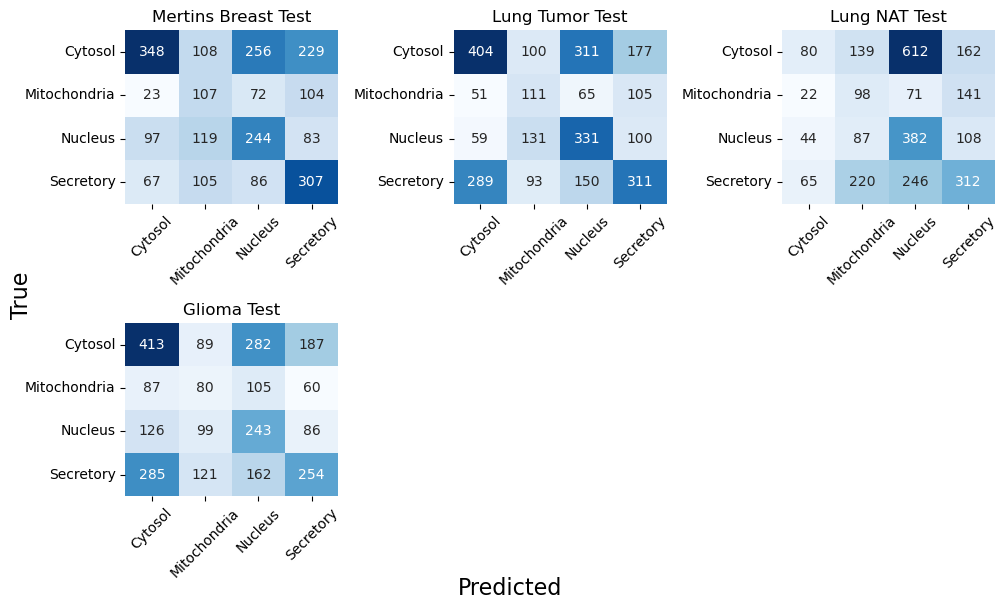

<Figure size 640x480 with 0 Axes>

In [24]:
# Set seed
#set_seed(Seed)

# Get the confusion matrix and precision and recall for the validation loader and all test loaders
cf_matrix_M, precision_M, recall_M, macro_f1_M, all_indices_M, all_predicted_labels_M, all_true_labels_M = calculate_metrics(M_test_loader, last_model)    
cf_matrix_lung_tumor, precision_lung_tumor, recall_lung_tumor, macro_f1_lung_tumor, all_indices_lung_tumor, all_predicted_labels_lung_tumor, all_true_labels_lung_tumor = calculate_metrics(lung_tumor_test_loader, last_model)
cf_matrix_lung_nat, precision_lung_nat, recall_lung_nat, macro_f1_lung_nat, all_indices_lung_nat, all_predicted_labels_lung_nat, all_true_labels_lung_nat = calculate_metrics(lung_nat_test_loader, last_model)
cf_matrix_glioma, precision_glioma, recall_glioma, macro_f1_glioma, all_indices_glioma, all_predicted_labels_glioma, all_true_labels_glioma = calculate_metrics(glioma_test_loader, last_model)

# Put them into a list
cf_matrices = [cf_matrix_M, cf_matrix_lung_tumor, cf_matrix_lung_nat, cf_matrix_glioma]
titles = ['Mertins Breast Test', 'Lung Tumor Test', 'Lung NAT Test', 'Glioma Test']

# Plot the confusion matrices
plot_confusion_matrices(cf_matrices, labels=int_to_label.values(), title=titles)

# Save figure into figure bank
figure3 = plt.gcf()

In [25]:
# Convert the predicted labels back to string labels
all_predicted_labels_M_str = [int_to_label[label] for label in all_predicted_labels_M]
all_predicted_labels_lung_tumor_str = [int_to_label[label] for label in all_predicted_labels_lung_tumor]
all_predicted_labels_lung_nat_str = [int_to_label[label] for label in all_predicted_labels_lung_nat]
all_predicted_labels_glioma_str = [int_to_label[label] for label in all_predicted_labels_glioma]

all_true_labels_M_str = [int_to_label[label] for label in all_true_labels_M]
all_true_labels_lung_tumor_str = [int_to_label[label] for label in all_true_labels_lung_tumor]
all_true_labels_lung_nat_str = [int_to_label[label] for label in all_true_labels_lung_nat]
all_true_labels_glioma_str = [int_to_label[label] for label in all_true_labels_glioma]

# Assemble each dataset's results into a dataframe
results_M = pd.DataFrame({
    'Index': all_indices_M,
    'Predicted_Label': all_predicted_labels_M_str,
    'True_Label': all_true_labels_M_str
})
results_lung_tumor = pd.DataFrame({
    'Index': all_indices_lung_tumor,
    'Predicted_Label': all_predicted_labels_lung_tumor_str,
    'True_Label': all_true_labels_lung_tumor_str
})
results_lung_nat = pd.DataFrame({
    'Index': all_indices_lung_nat,
    'Predicted_Label': all_predicted_labels_lung_nat_str,
    'True_Label': all_true_labels_lung_nat_str
})
results_glioma = pd.DataFrame({
    'Index': all_indices_glioma,
    'Predicted_Label': all_predicted_labels_glioma_str,
    'True_Label': all_true_labels_glioma_str
})
# Set index
results_M.set_index('Index', inplace=True)
results_lung_tumor.set_index('Index', inplace=True)
results_lung_nat.set_index('Index', inplace=True)
results_glioma.set_index('Index', inplace=True)

In [26]:
def summarize_by_compartment(results_df, compartments=None, return_lists=True, print_table=True):
    """
    Summarize totals, correct and incorrect counts per compartment for a results DataFrame.

    Parameters:
    - results_df: pd.DataFrame with columns 'Predicted_Label' and 'True_Label' and index = item IDs
    - compartments: list of compartment names to consider (defaults to ['Cytosol','Mitochondria','Nucleus','Secretory'])
    - return_lists: if True, also return dicts of correct/incorrect index lists per compartment
    - print_table: if True, prints the summary table

    Returns:
    - summary_df: pd.DataFrame indexed by compartment with columns ['Total','Correct','Incorrect']
    - correct_indices: dict compartment -> list of correctly predicted indices (if return_lists True)
    - incorrect_indices: dict compartment -> list of incorrectly predicted indices (if return_lists True)
    """
    if compartments is None:
        compartments = ['Cytosol', 'Mitochondria', 'Nucleus', 'Secretory']

    summary = []
    correct_indices = {}
    incorrect_indices = {}

    for comp in compartments:
        mask = results_df['True_Label'] == comp
        total = int(mask.sum())

        correct_mask = mask & (results_df['Predicted_Label'] == results_df['True_Label'])
        incorrect_mask = mask & (results_df['Predicted_Label'] != results_df['True_Label'])

        correct_list = results_df[correct_mask].index.tolist()
        incorrect_list = results_df[incorrect_mask].index.tolist()

        summary.append({'Compartment': comp, 'Total': total, 'Correct': len(correct_list), 'Incorrect': len(incorrect_list)})

        correct_indices[comp] = correct_list
        incorrect_indices[comp] = incorrect_list

    summary_df = pd.DataFrame(summary).set_index('Compartment')

    if print_table:
        print(summary_df)

    if return_lists:
        return summary_df, correct_indices, incorrect_indices
    else:
        return summary_df

# Usage
summary_M, correct_M, incorrect_M = summarize_by_compartment(results_M, print_table=False)
summary_lung_tumor, correct_lung_tumor, incorrect_lung_tumor = summarize_by_compartment(results_lung_tumor, print_table=False)
summary_lung_nat, correct_lung_nat, incorrect_lung_nat = summarize_by_compartment(results_lung_nat, print_table=False)
summary_glioma, correct_glioma, incorrect_glioma = summarize_by_compartment(results_glioma, print_table=False)

# Print combined summary for one dataset (example)
print("Mertins summary:")
print(summary_M)
print("\nLung Tumor summary:")
print(summary_lung_tumor)
print("\nLung NAT summary:")
print(summary_lung_nat)
print("\nGlioma summary:")
print(summary_glioma)

Mertins summary:
              Total  Correct  Incorrect
Compartment                            
Cytosol         941      348        593
Mitochondria    306      107        199
Nucleus         543      244        299
Secretory       565      307        258

Lung Tumor summary:
              Total  Correct  Incorrect
Compartment                            
Cytosol         992      404        588
Mitochondria    332      111        221
Nucleus         621      331        290
Secretory       843      311        532

Lung NAT summary:
              Total  Correct  Incorrect
Compartment                            
Cytosol         993       80        913
Mitochondria    332       98        234
Nucleus         621      382        239
Secretory       843      312        531

Glioma summary:
              Total  Correct  Incorrect
Compartment                            
Cytosol         971      413        558
Mitochondria    332       80        252
Nucleus         554      243        311
Secret

In [27]:
# find the overlap of correct predictions across all three datasets for each compartment
for compartment in ['Cytosol', 'Mitochondria', 'Nucleus', 'Secretory']:
    correct_indices_lists = [
        set(correct_M[compartment]),
        set(correct_lung_tumor[compartment]),
        set(correct_glioma[compartment])
    ]
    overlap = set.intersection(*correct_indices_lists)
    print(f"{compartment} correct prediction overlap across all datasets: {len(overlap)}")
print("")
for compartment in ['Cytosol', 'Mitochondria', 'Nucleus', 'Secretory']:
    incorrect_indices_lists = [
        set(incorrect_M[compartment]),
        set(incorrect_lung_tumor[compartment]),
        set(incorrect_glioma[compartment])
    ]
    overlap_incorrect = set.intersection(*incorrect_indices_lists)
    print(f"{compartment} incorrect prediction overlap across all datasets: {len(overlap_incorrect)}")

Cytosol correct prediction overlap across all datasets: 92
Mitochondria correct prediction overlap across all datasets: 8
Nucleus correct prediction overlap across all datasets: 115
Secretory correct prediction overlap across all datasets: 78

Cytosol incorrect prediction overlap across all datasets: 264
Mitochondria incorrect prediction overlap across all datasets: 106
Nucleus incorrect prediction overlap across all datasets: 112
Secretory incorrect prediction overlap across all datasets: 186


Observed shared correct counts across datasets:
{'Cytosol': 92, 'Mitochondria': 8, 'Nucleus': 115, 'Secretory': 78}


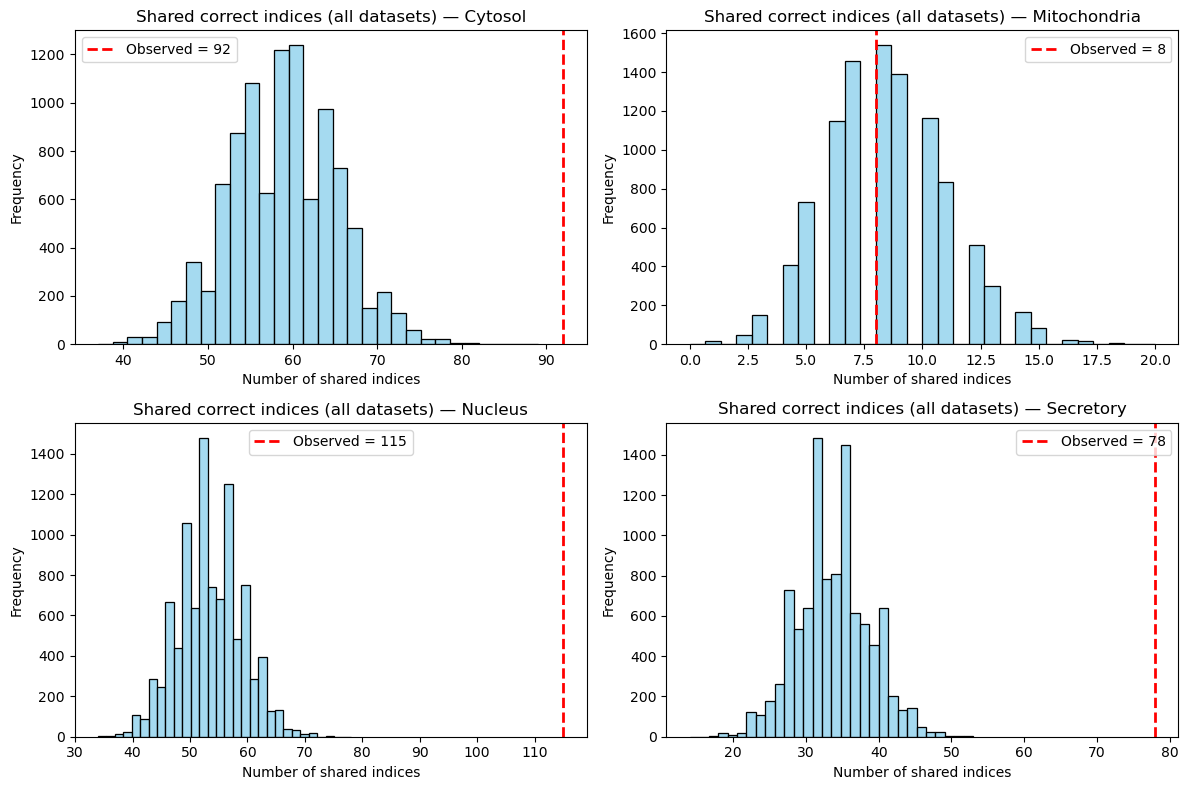

              sim_mean  sim_median   sim_std  observed
Cytosol        58.8836        59.0  6.290568      92.0
Mitochondria    8.3087         8.0  2.601693       8.0
Nucleus        53.4614        53.0  5.555458     115.0
Secretory      33.7104        34.0  4.951760      78.0


In [28]:
# Simulation: random sampling of "correct" indices per compartment across datasets,
# record shared (intersection) counts, repeat N times and plot distributions.
# Uses existing DataFrames: results_M, results_lung_tumor, results_glioma
# and existing Seed variable for reproducibility.

n_iter = 10000
compartments = ['Cytosol', 'Mitochondria', 'Nucleus', 'Secretory']
datasets = {
    'Mertins': results_M,
    'Lung_Tumor': results_lung_tumor,
    'Glioma': results_glioma
}
rng = np.random.RandomState(Seed if 'Seed' in globals() else 42)

# Prepare pools and observed correct counts
pools = {ds: {} for ds in datasets}
obs_correct_counts = {ds: {} for ds in datasets}
obs_correct_sets = {ds: {} for ds in datasets}

for ds_name, df in datasets.items():
    for comp in compartments:
        # pool: all indices (true label == comp) in this dataset
        pool_idx = df.index[df['True_Label'] == comp].tolist()
        pools[ds_name][comp] = pool_idx

        # observed correct indices: True_Label == comp AND Predicted_Label == True_Label
        correct_mask = (df['True_Label'] == comp) & (df['Predicted_Label'] == df['True_Label'])
        correct_idx = df.index[correct_mask].tolist()
        obs_correct_sets[ds_name][comp] = set(correct_idx)
        obs_correct_counts[ds_name][comp] = len(correct_idx)

# Compute observed shared counts (intersection of actual correct indices across datasets)
observed_shared = {}
for comp in compartments:
    sets_to_intersect = [obs_correct_sets[ds][comp] for ds in datasets]
    observed_shared[comp] = len(set.intersection(*sets_to_intersect))

print("Observed shared correct counts across datasets:")
print(observed_shared)

# Run simulation
shared_counts_sim = {comp: [] for comp in compartments}

for i in range(n_iter):
    sampled_sets = {ds: {} for ds in datasets}
    for ds_name in datasets:
        for comp in compartments:
            pool = pools[ds_name][comp]
            k = obs_correct_counts[ds_name][comp]
            # safety: cannot sample more than pool size
            k = min(k, len(pool))
            if k == 0:
                sampled = set()
            else:
                sampled = set(rng.choice(pool, size=k, replace=False))
            sampled_sets[ds_name][comp] = sampled

    # for each compartment compute intersection size across datasets (all datasets)
    for comp in compartments:
        sets_to_intersect = [sampled_sets[ds][comp] for ds in datasets]
        inter_size = len(set.intersection(*sets_to_intersect))
        shared_counts_sim[comp].append(inter_size)

# Plot distributions (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for ax, comp in zip(axes, compartments):
    data = shared_counts_sim[comp]
    sns.histplot(data, bins=30, kde=False, ax=ax, color='skyblue')
    ax.axvline(observed_shared[comp], color='red', linestyle='--', linewidth=2,
               label=f'Observed = {observed_shared[comp]}')
    ax.set_title(f'Shared correct indices (all datasets) — {comp}')
    ax.set_xlabel('Number of shared indices')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

# Optional: summarize results
summary_sim = pd.DataFrame({
    comp: {
        'sim_mean': np.mean(shared_counts_sim[comp]),
        'sim_median': np.median(shared_counts_sim[comp]),
        'sim_std': np.std(shared_counts_sim[comp]),
        'observed': observed_shared[comp]
    } for comp in compartments
}).T

print(summary_sim)

Observed shared incorrect counts across datasets:
{'Cytosol': 264, 'Mitochondria': 106, 'Nucleus': 112, 'Secretory': 186}


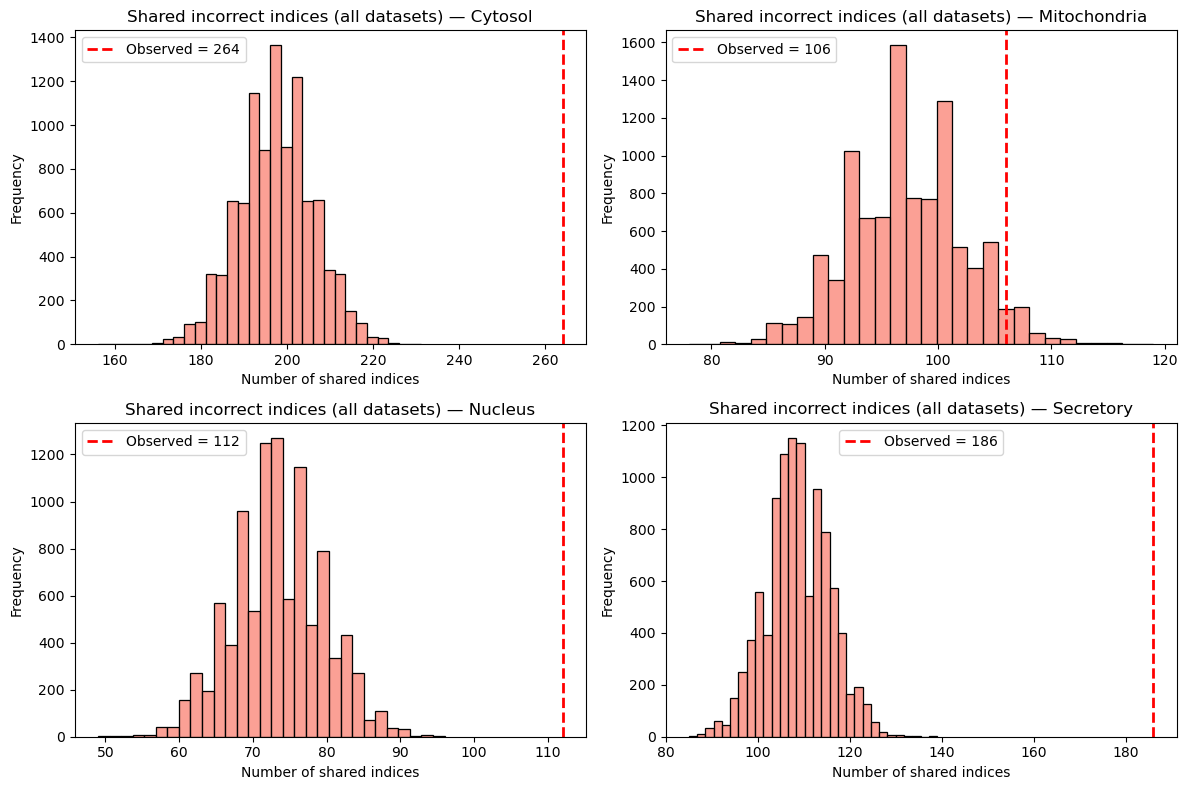

              sim_mean  sim_median   sim_std  observed
Cytosol       197.1817       197.0  8.674081     264.0
Mitochondria   97.2849        97.0  5.058036     106.0
Nucleus        73.4594        73.0  6.187160     112.0
Secretory     108.5239       108.0  6.890677     186.0


In [30]:
# Simulation and plotting for incorrect indices (same procedure as for correct indices)

# Uses existing variables: datasets, compartments, pools, n_iter, rng

# Prepare observed incorrect counts and sets
obs_incorrect_counts = {ds: {} for ds in datasets}
obs_incorrect_sets = {ds: {} for ds in datasets}

for ds_name, df in datasets.items():
    for comp in compartments:
        # pool: all indices (true label == comp) in this dataset (already available in pools)
        pool_idx = pools[ds_name][comp]

        # observed incorrect indices: True_Label == comp AND Predicted_Label != True_Label
        incorrect_mask = (df['True_Label'] == comp) & (df['Predicted_Label'] != df['True_Label'])
        incorrect_idx = df.index[incorrect_mask].tolist()
        obs_incorrect_sets[ds_name][comp] = set(incorrect_idx)
        obs_incorrect_counts[ds_name][comp] = len(incorrect_idx)

# Compute observed shared incorrect counts (intersection of actual incorrect indices across datasets)
observed_shared_incorrect = {}
for comp in compartments:
    sets_to_intersect = [obs_incorrect_sets[ds][comp] for ds in datasets]
    observed_shared_incorrect[comp] = len(set.intersection(*sets_to_intersect))

print("Observed shared incorrect counts across datasets:")
print(observed_shared_incorrect)

# Run simulation for incorrect indices
shared_counts_sim_incorrect = {comp: [] for comp in compartments}

for i in range(n_iter):
    sampled_sets = {ds: {} for ds in datasets}
    for ds_name in datasets:
        for comp in compartments:
            pool = pools[ds_name][comp]
            k = obs_incorrect_counts[ds_name][comp]
            k = min(k, len(pool))
            if k == 0:
                sampled = set()
            else:
                sampled = set(rng.choice(pool, size=k, replace=False))
            sampled_sets[ds_name][comp] = sampled

    for comp in compartments:
        sets_to_intersect = [sampled_sets[ds][comp] for ds in datasets]
        inter_size = len(set.intersection(*sets_to_intersect))
        shared_counts_sim_incorrect[comp].append(inter_size)

# Plot distributions (2x2)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for ax, comp in zip(axes, compartments):
    data = shared_counts_sim_incorrect[comp]
    sns.histplot(data, bins=30, kde=False, ax=ax, color='salmon')
    ax.axvline(observed_shared_incorrect[comp], color='red', linestyle='--', linewidth=2,
               label=f'Observed = {observed_shared_incorrect[comp]}')
    ax.set_title(f'Shared incorrect indices (all datasets) — {comp}')
    ax.set_xlabel('Number of shared indices')
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

# Summary statistics
summary_sim_incorrect = pd.DataFrame({
    comp: {
        'sim_mean': np.mean(shared_counts_sim_incorrect[comp]),
        'sim_median': np.median(shared_counts_sim_incorrect[comp]),
        'sim_std': np.std(shared_counts_sim_incorrect[comp]),
        'observed': observed_shared_incorrect[comp]
    } for comp in compartments
}).T

print(summary_sim_incorrect)

In [31]:
# Report 95% empirical CI (2.5th and 97.5th percentiles) for each simulated distribution
# and empirical one-sided p-value (proportion of sims >= observed)
correct_hi = []
print("Correct indices (shared across datasets):")
for comp in compartments:
    arr = np.asarray(shared_counts_sim[comp])
    # Sort the array
    sorted_arr = np.sort(arr)

    # Find the 95th percentile index
    hi = sorted_arr[n_iter * 95 // 100 - 1] # 95th percentile
    correct_hi.append(hi)
    lo = sorted_arr[0]  # 0th percentile

    obs = observed_shared[comp]
    p_ge = (arr >= obs).sum() / len(arr)
    print(f"  {comp:12s} 95% CI = [{lo:.1f}, {hi:.1f}]  observed = {obs}  p(>=obs) = {p_ge:.4f}")

incorrect_hi = []
print("\nIncorrect indices (shared across datasets):")
for comp in compartments:
    arr = np.asarray(shared_counts_sim_incorrect[comp])
    sorted_arr = np.sort(arr)
    hi = sorted_arr[n_iter * 95 // 100 - 1] # 95th percentile
    incorrect_hi.append(hi)
    lo = sorted_arr[0]  # 0th percentile
    obs = observed_shared_incorrect[comp]
    p_ge = (arr >= obs).sum() / len(arr)
    print(f"  {comp:12s} 95% CI = [{lo:.1f}, {hi:.1f}]  observed = {obs}  p(>=obs) = {p_ge:.4f}")

Correct indices (shared across datasets):
  Cytosol      95% CI = [37.0, 69.0]  observed = 92  p(>=obs) = 0.0000
  Mitochondria 95% CI = [0.0, 13.0]  observed = 8  p(>=obs) = 0.6044
  Nucleus      95% CI = [34.0, 63.0]  observed = 115  p(>=obs) = 0.0000
  Secretory    95% CI = [14.0, 42.0]  observed = 78  p(>=obs) = 0.0000

Incorrect indices (shared across datasets):
  Cytosol      95% CI = [156.0, 211.0]  observed = 264  p(>=obs) = 0.0000
  Mitochondria 95% CI = [78.0, 106.0]  observed = 106  p(>=obs) = 0.0526
  Nucleus      95% CI = [49.0, 84.0]  observed = 112  p(>=obs) = 0.0000
  Secretory    95% CI = [85.0, 120.0]  observed = 186  p(>=obs) = 0.0000


Cytosol correct prediction overlap across all datasets: 92
Mitochondria correct prediction overlap across all datasets: 8
Nucleus correct prediction overlap across all datasets: 115
Secretory correct prediction overlap across all datasets: 78


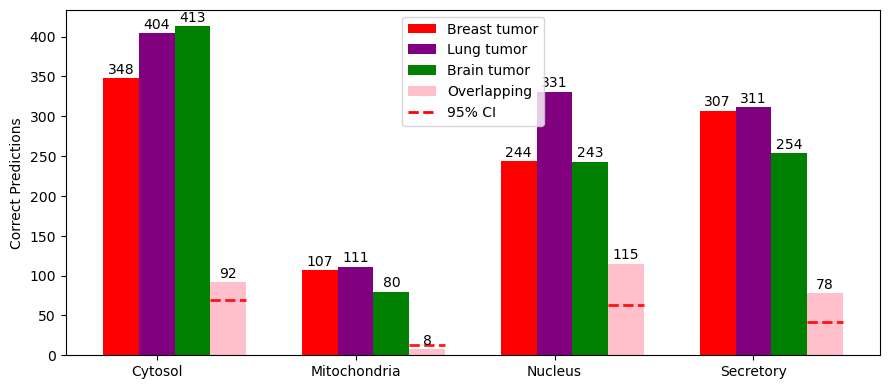

In [34]:
# Bar plot of correct predictions by compartment using results_* dataframes
compartments = ['Cytosol', 'Mitochondria', 'Nucleus', 'Secretory']

# Per-set correct counts from results dataframes
correct_counts = {
    'Mertins': [int(((results_M['True_Label'] == comp) & (results_M['Predicted_Label'] == results_M['True_Label'])).sum()) for comp in compartments],
    'Lung_Tumor': [int(((results_lung_tumor['True_Label'] == comp) & (results_lung_tumor['Predicted_Label'] == results_lung_tumor['True_Label'])).sum()) for comp in compartments],
    'Glioma': [int(((results_glioma['True_Label'] == comp) & (results_glioma['Predicted_Label'] == results_glioma['True_Label'])).sum()) for comp in compartments]
}

# Shared correct across all three datasets:
overlap_correct_counts=[]
for compartment in ['Cytosol', 'Mitochondria', 'Nucleus', 'Secretory']:
    correct_indices_lists = [
        set(correct_M[compartment]),
        set(correct_lung_tumor[compartment]),
        set(correct_glioma[compartment])
    ]
    overlap_correct_counts.append(set.intersection(*correct_indices_lists))
    print(f"{compartment} correct prediction overlap across all datasets: {len(overlap_correct_counts[-1])}")

# 95% CI upper bound from the simulation for shared correct
ci_upper = correct_hi

# Plot
x = np.arange(len(compartments))
width = 0.18

plt.figure(figsize=(9, 4))
plt.bar(x - width, correct_counts['Mertins'], width, label='Breast tumor', color='red')
plt.bar(x, correct_counts['Lung_Tumor'], width, label='Lung tumor', color='purple')
plt.bar(x + width, correct_counts['Glioma'], width, label='Brain tumor', color='green')
plt.bar(x + 2 * width, [len(s) for s in overlap_correct_counts], width, label='Overlapping', color='pink')

# Add red dashed CI-upper lines over each pink bar
for i, ci in enumerate(ci_upper):
    if not np.isnan(ci):
        bar_left = x[i] + 2 * width - width/2
        bar_right = x[i] + 2 * width + width/2
        plt.plot([bar_left, bar_right], [ci, ci], color='red', linestyle='--', linewidth=2, alpha=0.9)

# Add CI proxy to legend
handles, labels = plt.gca().get_legend_handles_labels()
ci_line = mlines.Line2D([], [], color='red', linestyle='--', linewidth=2, label='95% CI')
handles.append(ci_line)
labels.append(ci_line.get_label())
plt.legend(handles, labels)

# Add count labels
for i in range(len(compartments)):
    plt.text(x[i] - width, correct_counts['Mertins'][i] + 2, str(correct_counts['Mertins'][i]), ha='center', va='bottom', fontsize=10)
    plt.text(x[i], correct_counts['Lung_Tumor'][i] + 2, str(correct_counts['Lung_Tumor'][i]), ha='center', va='bottom', fontsize=10)
    plt.text(x[i] + width, correct_counts['Glioma'][i] + 2, str(correct_counts['Glioma'][i]), ha='center', va='bottom', fontsize=10)
    plt.text(x[i] + 2 * width, [len(s) for s in overlap_correct_counts][i] + 2, str([len(s) for s in overlap_correct_counts][i]), ha='center', va='bottom', fontsize=10)

plt.ylabel('Correct Predictions')
plt.xticks(x, compartments)
plt.tight_layout()

# Save figure
plt.savefig(Path(enrichr_path)/'Protein_Tumor_Correct_Predictions_by_Compartment_shared_modified1.pdf', dpi=300)

Cytosol incorrect prediction overlap across all datasets: 264
Mitochondria incorrect prediction overlap across all datasets: 106
Nucleus incorrect prediction overlap across all datasets: 112
Secretory incorrect prediction overlap across all datasets: 186


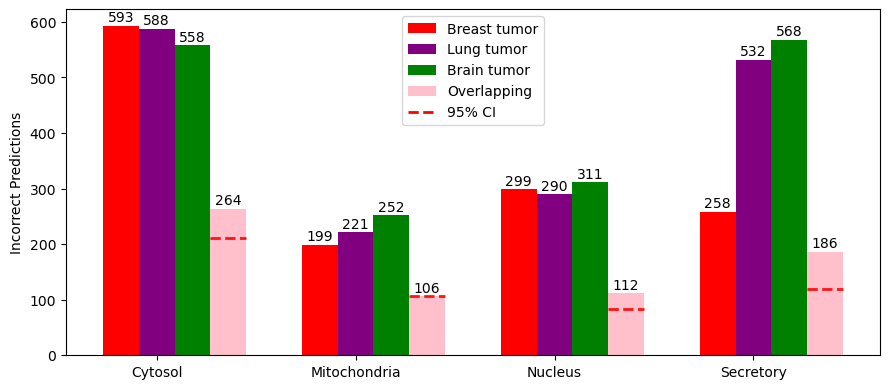

In [35]:
# Bar plot of incorrect predictions by compartment (same style as the correct-predictions plot)

compartments = ['Cytosol', 'Mitochondria', 'Nucleus', 'Secretory']

# Per-set incorrect counts from results dataframes
incorrect_counts = {
    'Mertins': [int(((results_M['True_Label'] == comp) & (results_M['Predicted_Label'] != results_M['True_Label'])).sum()) for comp in compartments],
    'Lung_Tumor': [int(((results_lung_tumor['True_Label'] == comp) & (results_lung_tumor['Predicted_Label'] != results_lung_tumor['True_Label'])).sum()) for comp in compartments],
    'Glioma': [int(((results_glioma['True_Label'] == comp) & (results_glioma['Predicted_Label'] != results_glioma['True_Label'])).sum()) for comp in compartments]
}

# Shared incorrect across all three datasets (only consider indices present in all three result dataframes)
overlap_incorrect_counts=[]
for compartment in ['Cytosol', 'Mitochondria', 'Nucleus', 'Secretory']:
    incorrect_indices_lists = [
        set(incorrect_M[compartment]),
        set(incorrect_lung_tumor[compartment]),
        set(incorrect_glioma[compartment])
    ]
    overlap_incorrect = set.intersection(*incorrect_indices_lists)
    overlap_incorrect_counts.append(overlap_incorrect)
    print(f"{compartment} incorrect prediction overlap across all datasets: {len(overlap_incorrect)}")

# 95% CI upper bound from the simulation for shared incorrect
ci_upper_incorrect = incorrect_hi

# Plot
x = np.arange(len(compartments))
width = 0.18

plt.figure(figsize=(9, 4))
plt.bar(x - width, incorrect_counts['Mertins'], width, label='Breast tumor', color='red')
plt.bar(x, incorrect_counts['Lung_Tumor'], width, label='Lung tumor', color='purple')
plt.bar(x + width, incorrect_counts['Glioma'], width, label='Brain tumor', color='green')
plt.bar(x + 2 * width, [len(s) for s in overlap_incorrect_counts], width, label='Overlapping', color='pink')

# Add red dashed CI-upper lines over each pink bar
for i, ci in enumerate(ci_upper_incorrect):
    if not np.isnan(ci):
        bar_left = x[i] + 2 * width - width/2
        bar_right = x[i] + 2 * width + width/2
        plt.plot([bar_left, bar_right], [ci, ci], color='red', linestyle='--', linewidth=2, alpha=0.9)

# Add CI proxy to legend
handles, labels = plt.gca().get_legend_handles_labels()
ci_line = mlines.Line2D([], [], color='red', linestyle='--', linewidth=2, label='95% CI')
handles.append(ci_line)
labels.append(ci_line.get_label())
plt.legend(handles, labels)

# Add count labels
for i in range(len(compartments)):
    plt.text(x[i] - width, incorrect_counts['Mertins'][i] + 2, str(incorrect_counts['Mertins'][i]), ha='center', va='bottom', fontsize=10)
    plt.text(x[i], incorrect_counts['Lung_Tumor'][i] + 2, str(incorrect_counts['Lung_Tumor'][i]), ha='center', va='bottom', fontsize=10)
    plt.text(x[i] + width, incorrect_counts['Glioma'][i] + 2, str(incorrect_counts['Glioma'][i]), ha='center', va='bottom', fontsize=10)
    plt.text(x[i] + 2 * width, [len(s) for s in overlap_incorrect_counts][i] + 2, str([len(s) for s in overlap_incorrect_counts][i]), ha='center', va='bottom', fontsize=10)

plt.ylabel('Incorrect Predictions')
plt.xticks(x, compartments)
plt.tight_layout()

# Save figure
figure_incorrect = plt.gcf()
figure_incorrect.savefig(Path(enrichr_path)/'Protein_Tumor_Incorrect_Predictions_by_Compartment_shared_modified1.pdf', dpi=300)

### Enrichment

Shared incorrect gene counts per compartment:
  Cytosol      : 264 genes
  Mitochondria : 106 genes
  Nucleus      : 112 genes
  Secretory    : 186 genes


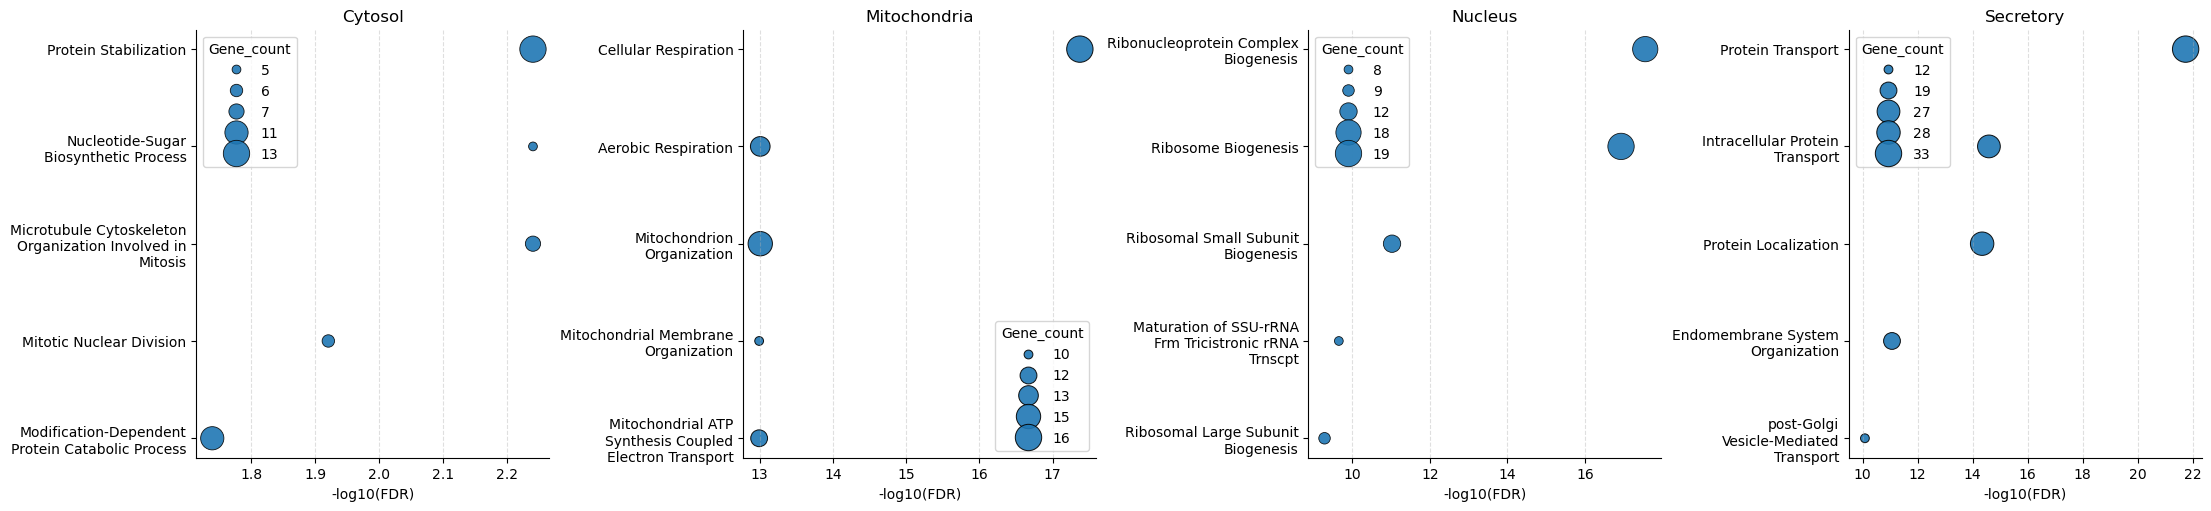

Saved BP top-5 figure to: /home/ec2-user/Jul2025/Fig5_Enrichr_Ranked_Prot_Modified_Marker_Localization/Protein_Tumor_Shared_Incorrect_GO_BP_top5_modified1.pdf
Saved full BP enrichment tables to: /home/ec2-user/Jul2025/Fig5_Enrichr_Ranked_Prot_Modified_Marker_Localization/Protein_Tumor_Shared_Incorrect_GO_BP_results_modified1.xlsx


In [38]:
from pathlib import Path
import seaborn as sns
import numpy as np
import pandas as pd
from textwrap import fill
import matplotlib.pyplot as plt
import gseapy as gp

def run_shared_incorrect_enrichment_bp_gsea(compartments=None, top_n=5, figname='Protein_Tumor_Shared_Incorrect_GO_BP_top5_1x4.pdf'):
    """
    Run Enrichr (GO Biological Process) on shared incorrect gene-sets (intersection across datasets)
    and plot only the top_n terms per compartment (single saved figure). Saves full GSEA tables
    (all terms) to an Excel workbook. Uses globals:
      - obs_incorrect_sets : dict of observed incorrect sets per dataset (from previous cells)
      - enrichr_path : output directory (if present)
    Returns:
      - shared_incorrect_sets : dict compartment -> set(genes)
      - results_dict : dict compartment -> full enrichment results DataFrame
    """
    # build shared (intersection) incorrect sets across datasets using obs_incorrect_sets from globals
    if compartments is None:
        compartments = ['Cytosol', 'Mitochondria', 'Nucleus', 'Secretory']

    ds_keys = list(obs_incorrect_sets.keys()) if 'obs_incorrect_sets' in globals() else []
    shared_incorrect_sets = {}
    for comp in compartments:
        sets_to_intersect = [obs_incorrect_sets[ds][comp] for ds in ds_keys]
        shared_incorrect_sets[comp] = set.intersection(*sets_to_intersect) if sets_to_intersect else set()
    
    print("Shared incorrect gene counts per compartment:")
    for comp in compartments:
        print(f"  {comp:12s} : {len(shared_incorrect_sets[comp])} genes")

    # plotting setup (one panel per compartment)
    fig, axes = plt.subplots(1, len(compartments), figsize=(22, 5), constrained_layout=True)
    if len(compartments) == 1:
        axes = [axes]

    results_dict = {}

    def wrap_label(label, width=60):
        words = str(label).split()
        lines = []
        cur = ''
        for w in words:
            if len(cur) + len(w) + 1 <= width:
                cur = (cur + ' ' + w).strip()
            else:
                lines.append(cur)
                cur = w
        if cur:
            lines.append(cur)
        return '\n'.join(lines)

    for ax, comp in zip(axes, compartments):
        genes = sorted(shared_incorrect_sets.get(comp, []))
        if len(genes) == 0:
            ax.text(0.5, 0.5, f'No shared incorrect\ngenes for {comp}', ha='center', va='center')
            ax.set_axis_off()
            results_dict[comp] = pd.DataFrame()
            continue

        try:
            enr = gp.enrichr(
                gene_list=genes,
                gene_sets='GO_Biological_Process_2025',
                organism='Human',
                outdir=None,
                cutoff=0.05
            )
            res = enr.results.copy()
        except Exception as e:
            print(f"Enrichr failed for {comp} (BP): {e}")
            res = pd.DataFrame()

        if res.empty:
            ax.text(0.5, 0.5, f'No significant terms\nfor {comp}', ha='center', va='center')
            ax.set_axis_off()
            results_dict[comp] = res
            continue

        # Prepare full results fields
        res['-log10(FDR)'] = -np.log10(res['Adjusted P-value'].replace(0, 1e-300))
        res['Gene_count'] = res['Overlap'].str.split('/').str[0].astype(int)
        res['BP_term'] = res['Term'].str.replace(r'\s*\(GO:\d+\)', '', regex=True)
        res['BP_term_wrapped'] = res['BP_term'].apply(lambda x: wrap_label(x, width=25))
        res = res.sort_values('-log10(FDR)', ascending=False)
        results_dict[comp] = res  # store full results

        # plot only top_n terms
        res_top = res.head(top_n).copy()
        if res_top.empty:
            ax.text(0.5, 0.5, f'No significant terms\nfor {comp}', ha='center', va='center')
            ax.set_axis_off()
            continue

        sns.scatterplot(
            data=res_top,
            x='-log10(FDR)',
            y='BP_term_wrapped',
            size='Gene_count',
            sizes=(40, 360),
            #hue='-log10(FDR)',
            #palette='viridis',
            edgecolor='black',
            alpha=0.9,
            legend=True,
            ax=ax
        )
        ax.set_title(comp)
        ax.set_xlabel('-log10(FDR)')
        ax.set_ylabel('')
        ax.grid(axis='x', linestyle='--', alpha=0.4)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # save single combined figure (top_n terms)
    out_dir = Path(enrichr_path) if 'enrichr_path' in globals() else Path('.')
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / figname
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()

    # Save full enrichment tables (all terms) to Excel workbook
    excel_path = out_dir / figname.replace('BP_top5_modified1.pdf', 'BP_results_modified1.xlsx').replace('BP_top5_modified1.png', 'BP_results_modified1.xlsx')
    with pd.ExcelWriter(excel_path) as writer:
        for comp, df in results_dict.items():
            # write full results (even if empty) to each sheet
            if df.empty:
                pd.DataFrame().to_excel(writer, sheet_name=comp, index=False)
            else:
                df.to_excel(writer, sheet_name=comp, index=False)

    print(f"Saved BP top-{top_n} figure to: {out_path}")
    print(f"Saved full BP enrichment tables to: {excel_path}")

    return shared_incorrect_sets, results_dict

# Run the BP enrichment for shared incorrect lists (only one figure saved, top 5)
shared_incorrect_sets_bp, shared_incorrect_results_bp = run_shared_incorrect_enrichment_bp_gsea(
    compartments=['Cytosol', 'Mitochondria', 'Nucleus', 'Secretory'],
    top_n=5,
    figname='Protein_Tumor_Shared_Incorrect_GO_BP_top5_modified1.pdf'
)